In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
df = pd.read_csv("Amazon_Reviews.csv", sep=None, engine="python")
print(df.head())
print(df.columns)

      Reviewer Name                     Profile Link Country Review Count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   
2          p fisher  /users/546cfcf1000064000197b88f      GB   90 reviews   
3         Greg Dunn  /users/62c35cdbacc0ea0012ccaffa      AU    5 reviews   
4     Sheila Hannah  /users/5ddbe429478d88251550610e      GB    8 reviews   

                Review Date                  Rating  \
0  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   
2  2024-09-16T21:47:39.000Z  Rated 1 out of 5 stars   
3  2024-09-17T07:15:49.000Z  Rated 1 out of 5 stars   
4  2024-09-16T18:37:17.000Z  Rated 1 out of 5 stars   

                                      Review Title  \
0       A Store That Doesn't Want to Sell Anything   
1           Had multiple orders one turned up and…   
2                      I informed these repr

In [20]:
# dataset ki basic info
df.info()

# missing values check karo
print(df.isnull().sum())

# dataset size dekho
print(df.shape)

#duplicate row and check karo
print(df.duplicated().sum())

# review text
print(df['Review Text'].head())

# rating distribution
print(df['Rating'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Reviewer Name       0 non-null      object 
 1   Profile Link        0 non-null      object 
 2   Country             0 non-null      object 
 3   Review Count        0 non-null      object 
 4   Review Date         0 non-null      object 
 5   Rating              0 non-null      float64
 6   Review Title        0 non-null      object 
 7   Review Text         0 non-null      object 
 8   Date of Experience  0 non-null      object 
 9   Sentiment           0 non-null      float64
dtypes: float64(2), object(8)
memory usage: 0.0+ bytes
Reviewer Name         0
Profile Link          0
Country               0
Review Count          0
Review Date           0
Rating                0
Review Title          0
Review Text           0
Date of Experience    0
Sentiment             0
dtype: int64
(0, 10)
0
Series

In [18]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df=df.dropna(subset=['Rating'])
def sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"
    
df['Sentiment'] = df['Rating'].apply(sentiment)
print(df[['Rating','Sentiment']].head())

Empty DataFrame
Columns: [Rating, Sentiment]
Index: []


In [19]:
print(df.columns)
print(df.head())
print(df['Rating'].head(10))
print(df['Rating'].dtype)

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience', 'Sentiment'],
      dtype='object')
Empty DataFrame
Columns: [Reviewer Name, Profile Link, Country, Review Count, Review Date, Rating, Review Title, Review Text, Date of Experience, Sentiment]
Index: []
Series([], Name: Rating, dtype: float64)
float64


In [2]:
import pandas as pd 
df=pd.read_csv("Amazon_Reviews.csv",sep=None, engine="python")
print(df.shape)
print(df.head())

(21214, 9)
      Reviewer Name                     Profile Link Country Review Count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   
2          p fisher  /users/546cfcf1000064000197b88f      GB   90 reviews   
3         Greg Dunn  /users/62c35cdbacc0ea0012ccaffa      AU    5 reviews   
4     Sheila Hannah  /users/5ddbe429478d88251550610e      GB    8 reviews   

                Review Date                  Rating  \
0  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   
2  2024-09-16T21:47:39.000Z  Rated 1 out of 5 stars   
3  2024-09-17T07:15:49.000Z  Rated 1 out of 5 stars   
4  2024-09-16T18:37:17.000Z  Rated 1 out of 5 stars   

                                      Review Title  \
0       A Store That Doesn't Want to Sell Anything   
1           Had multiple orders one turned up and…   
2                      I informed

In [6]:
from textblob import TextBlob
def get_sentiment(text):
    analysis=TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return"Positive"
    elif analysis.sentiment.polarity < 0:
        return"Negative"
    else:
        return"Neutral"
    
df["Sentiment"]=df["Review Text"].apply(get_sentiment)
print(df[["Review Text","Sentiment"]].head())

                                         Review Text Sentiment
0  I registered on the website, tried to order a ...  Negative
1  Had multiple orders one turned up and driver h...  Negative
2  I informed these reprobates that I WOULD NOT B...  Negative
3  I have bought from Amazon before and no proble...  Negative
4  If I could give a lower rate I would! I cancel...   Neutral


In [7]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    10618
Negative     8344
Neutral      2252
Name: count, dtype: int64


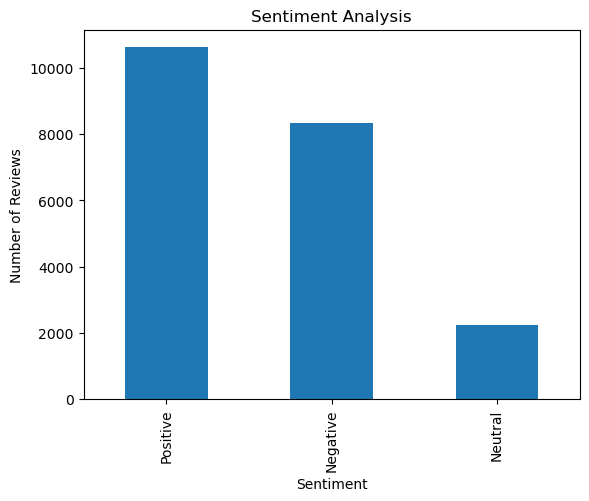

In [9]:
import matplotlib.pyplot as plt
df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

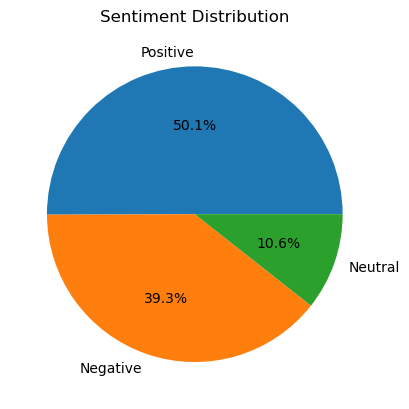

In [10]:
import matplotlib.pyplot as plt
df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

In [11]:
df.to_csv("Amazon_Reviews_Sentiment.csv", index=False)
print("File Saved Successfully!")

File Saved Successfully!
